# 03. Пуассоновский процесс

**Статус:** завершено

В этом ноутбуке мы изучаем пуассоновский процесс как модель случайного потока событий: заявки, звонки, сделки, отказы оборудования, страховые случаи. Помимо базового однородного процесса разберём экспоненциальные времена ожидания, свойство отсутствия памяти, неоднородную интенсивность, суперпозицию, прореживание и мартингальную интуицию.

## Теория и интуиция

Пуассоновский процесс $N(t)$ — это счётный процесс: $N(t)$ показывает, сколько событий произошло к моменту времени $t$. Для однородного процесса с интенсивностью $\lambda>0$ выполняется:

$$
N(0)=0,
$$

$$
N(t)-N(s) \sim \mathrm{Poisson}(\lambda(t-s)), \qquad 0\le s<t,
$$

а приращения на непересекающихся интервалах независимы. Отсюда сразу следуют формулы

$$
\mathbb{E}[N(t)] = \lambda t, \qquad \mathrm{Var}(N(t)) = \lambda t.
$$

Интуитивно $\lambda$ — среднее число событий в единицу времени. Если $\lambda=2.5$, то за 10 единиц времени мы ожидаем около 25 событий, но фактическое число случайно.

Эквивалентное описание: времена между соседними событиями независимы и имеют экспоненциальное распределение:

$$
T_i \sim \mathrm{Exp}(\lambda), \qquad \mathbb{E}[T_i]=\frac{1}{\lambda}.
$$

Это не просто техническая формула. Экспоненциальное распределение имеет свойство отсутствия памяти:

$$
\mathbb{P}(T>s+t\mid T>s)=\mathbb{P}(T>t).
$$

То есть если событие уже долго не происходило, это само по себе не делает его «более срочным» в модели с постоянной интенсивностью.

## Импорты и функции

Основная логика находится в `Scripts/poisson_process.py`: симуляции траекторий, времена ожидания, неоднородный процесс, суперпозиция, прореживание и визуализации.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.poisson_process import (
    calculate_cumulative_intensity_for_sinusoidal_poisson_process,
    calculate_empirical_mean_and_variance_across_poisson_paths,
    calculate_theoretical_mean_and_variance_for_homogeneous_poisson_process,
    convert_event_times_to_count_paths,
    plot_exponential_waiting_time_distribution,
    plot_nonhomogeneous_poisson_intensity_and_mean,
    plot_poisson_empirical_and_theoretical_mean_variance,
    plot_poisson_process_sample_paths,
    plot_poisson_terminal_distribution_with_theory,
    simulate_exponential_waiting_times,
    simulate_multiple_homogeneous_poisson_process_paths_by_increments,
    simulate_nonhomogeneous_poisson_process_paths_by_thinning,
    simulate_superposed_poisson_terminal_counts,
    simulate_thinned_poisson_terminal_counts,
)

## 1. Ступенчатые траектории однородного процесса

Пуассоновский процесс растёт скачками на единицу: между событиями он постоянен, в момент события увеличивается. В отличие от броуновского движения, здесь траектория не непрерывная, а ступенчатая.

,N(10)
Траектория 1,23
Траектория 2,28
Траектория 3,23
Траектория 4,27
Траектория 5,33
Траектория 6,29


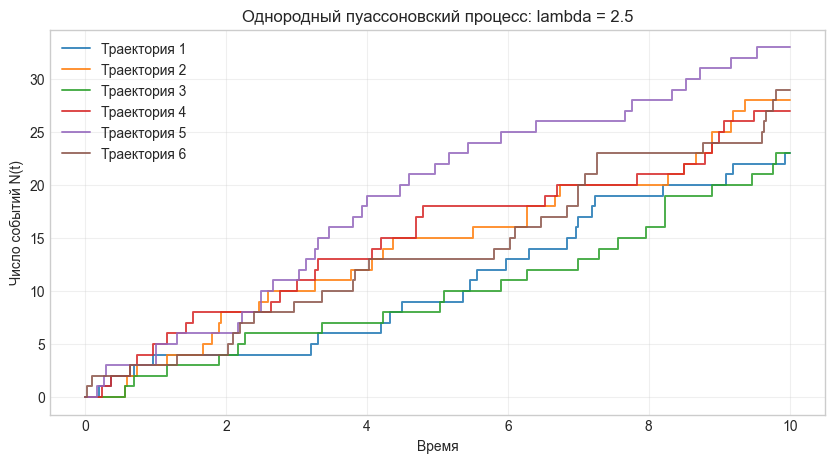

In [2]:
poisson_time_grid, poisson_paths = simulate_multiple_homogeneous_poisson_process_paths_by_increments(
    number_of_paths=6,
    number_of_time_steps=300,
    final_time=10.0,
    intensity=2.5,
    random_seed=42,
)

plot_poisson_process_sample_paths(
    time_grid=poisson_time_grid,
    poisson_paths=poisson_paths,
    number_of_paths_to_plot=6,
    title="Однородный пуассоновский процесс: lambda = 2.5",
);

pd.DataFrame(
    {"N(10)": poisson_paths[:, -1]},
    index=[f"Траектория {index}" for index in range(1, 7)],
)

На графике видны ступени: процесс ждёт следующее событие, затем мгновенно увеличивается на 1. Все траектории имеют одну интенсивность $\lambda=2.5$, но конечное число событий разное. Это важная особенность счётных процессов: интенсивность задаёт средний темп, а не жёсткое расписание.

Если бы события происходили детерминированно, траектории были бы почти прямыми. Здесь же интервалы ожидания случайны, поэтому одни траектории в начале быстро набирают события, другие долго стоят на месте.

## 2. Среднее, дисперсия и распределение конечного числа событий

Проверим две центральные формулы:

$$
\mathbb{E}[N(t)] = \lambda t, \qquad \mathrm{Var}(N(t)) = \lambda t.
$$

У пуассоновского распределения среднее и дисперсия совпадают. Это очень узнаваемый след модели: если в данных дисперсия сильно больше среднего, простой пуассоновский процесс может быть слишком бедным.

,Время,Эмпирическое среднее,Эмпирическая дисперсия,Теория lambda*t
0,2.5,6.2575,6.4052,6.25
1,5.0,12.5215,13.0465,12.50
2,10.0,24.9765,25.8019,25.00


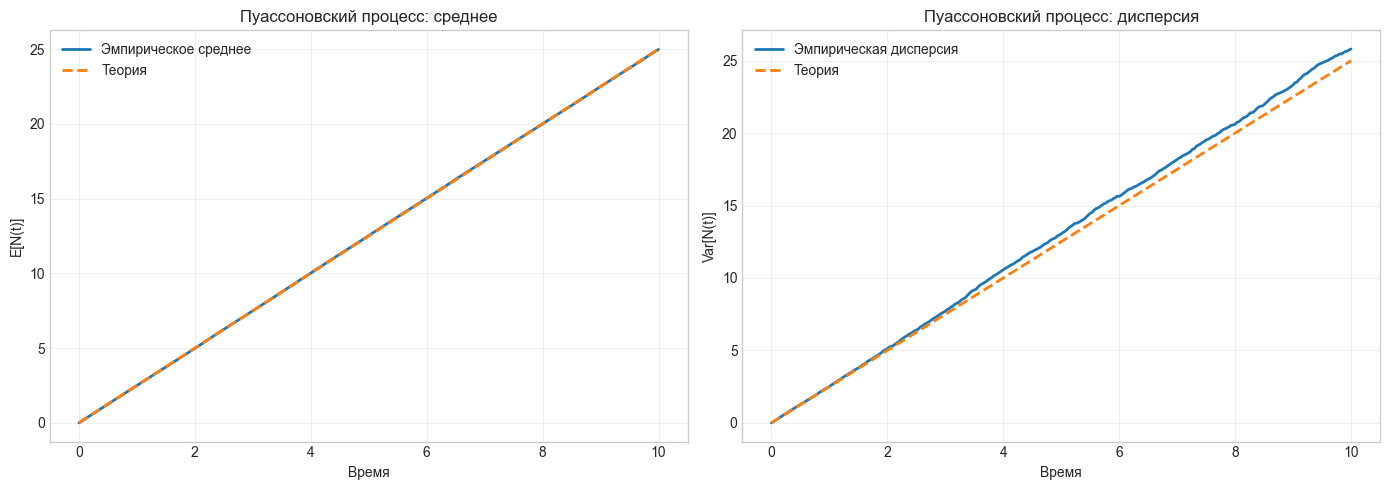

In [3]:
large_poisson_time_grid, large_poisson_paths = simulate_multiple_homogeneous_poisson_process_paths_by_increments(
    number_of_paths=6000,
    number_of_time_steps=300,
    final_time=10.0,
    intensity=2.5,
    random_seed=123,
)

poisson_empirical_mean, poisson_empirical_variance = calculate_empirical_mean_and_variance_across_poisson_paths(
    large_poisson_paths
)
poisson_theoretical_mean, poisson_theoretical_variance = calculate_theoretical_mean_and_variance_for_homogeneous_poisson_process(
    time_grid=large_poisson_time_grid,
    intensity=2.5,
)

plot_poisson_empirical_and_theoretical_mean_variance(
    time_grid=large_poisson_time_grid,
    empirical_mean=poisson_empirical_mean,
    empirical_variance=poisson_empirical_variance,
    theoretical_mean=poisson_theoretical_mean,
    theoretical_variance=poisson_theoretical_variance,
    title_prefix="Пуассоновский процесс",
);

selected_poisson_indices = [75, 150, 300]
pd.DataFrame(
    {
        "Время": large_poisson_time_grid[selected_poisson_indices],
        "Эмпирическое среднее": poisson_empirical_mean[selected_poisson_indices],
        "Эмпирическая дисперсия": poisson_empirical_variance[selected_poisson_indices],
        "Теория lambda*t": poisson_theoretical_mean[selected_poisson_indices],
    }
)

,Показатель,Значение
0,Среднее N(10),24.9765
1,Дисперсия N(10),25.8019
2,5%-квантиль,17.0000
3,Медиана,25.0000
4,95%-квантиль,34.0000


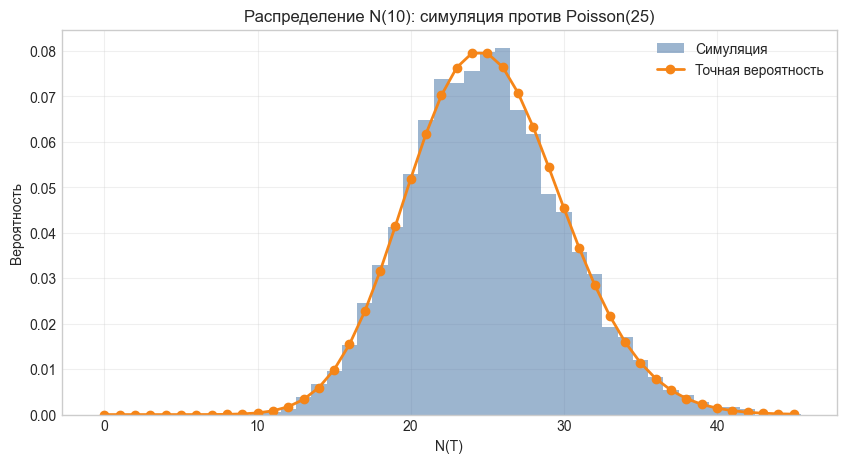

In [4]:
terminal_poisson_counts = large_poisson_paths[:, -1]

plot_poisson_terminal_distribution_with_theory(
    terminal_counts=terminal_poisson_counts,
    theoretical_mean=25.0,
    title="Распределение N(10): симуляция против Poisson(25)",
);

pd.DataFrame(
    {
        "Показатель": ["Среднее N(10)", "Дисперсия N(10)", "5%-квантиль", "Медиана", "95%-квантиль"],
        "Значение": [
            terminal_poisson_counts.mean(),
            terminal_poisson_counts.var(),
            np.quantile(terminal_poisson_counts, 0.05),
            np.quantile(terminal_poisson_counts, 0.50),
            np.quantile(terminal_poisson_counts, 0.95),
        ],
    }
)

Симуляция хорошо совпадает с теорией. В моменты `2.5`, `5.0` и `10.0` эмпирические средние равны примерно `6.2575`, `12.5215` и `24.9765`, а теория даёт `6.25`, `12.5` и `25.0`.

Дисперсия тоже близка к тем же значениям: например, в момент `10.0` она равна `25.8019`. Конечное распределение почти совпадает с `Poisson(25)`: медиана равна `25`, а центральные 90% наблюдений примерно лежат от `17` до `34` событий.

Математически полезно помнить ещё одну вещь: процесс

$$
M(t)=N(t)-\lambda t
$$

является мартингалом. Интуитивно это означает, что после вычитания ожидаемого линейного тренда у процесса не остаётся предсказуемого направления.

## 3. Времена ожидания и отсутствие памяти

Если события образуют однородный пуассоновский процесс, времена между событиями имеют экспоненциальное распределение. Это делает модель особенно удобной для потоков заявок: после каждого события процесс как будто начинается заново.

,Показатель,Значение
0,Среднее время ожидания,0.3952
1,Дисперсия времени ожидания,0.1579
2,P(T > 0.8) по симуляции,0.1311
3,P(T > 0.8) по теории,0.1353
4,P(T > 1.3 | T > 0.5) по симуляции,0.1378


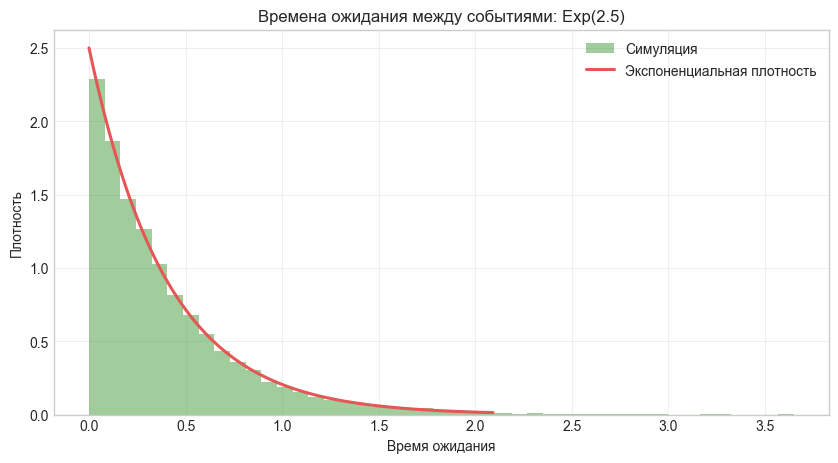

In [5]:
waiting_times = simulate_exponential_waiting_times(
    number_of_waiting_times=10000,
    intensity=2.5,
    random_seed=456,
)

plot_exponential_waiting_time_distribution(
    waiting_times=waiting_times,
    intensity=2.5,
    title="Времена ожидания между событиями: Exp(2.5)",
);

memory_threshold = 0.5
extra_wait = 0.8
conditional_probability = np.mean(waiting_times[waiting_times > memory_threshold] > memory_threshold + extra_wait)
unconditional_probability = np.mean(waiting_times > extra_wait)
theoretical_probability = np.exp(-2.5 * extra_wait)

pd.DataFrame(
    {
        "Показатель": [
            "Среднее время ожидания",
            "Дисперсия времени ожидания",
            "P(T > 0.8) по симуляции",
            "P(T > 0.8) по теории",
            "P(T > 1.3 | T > 0.5) по симуляции",
        ],
        "Значение": [
            waiting_times.mean(),
            waiting_times.var(),
            unconditional_probability,
            theoretical_probability,
            conditional_probability,
        ],
    }
)

Среднее время ожидания получилось `0.3952`, что близко к теоретическому $1/2.5=0.4$. Дисперсия равна `0.1579`, а теория для экспоненциального распределения даёт $1/\lambda^2=0.16$.

Вероятность ждать больше `0.8` по симуляции равна примерно `0.1311`, а теория даёт `0.1353`. Условная вероятность `P(T>1.3 | T>0.5)` оказывается близкой к той же величине. Это и есть отсутствие памяти: если мы уже ждали 0.5, распределение дополнительного ожидания не меняется.

## 4. Неоднородный пуассоновский процесс

В реальных потоках интенсивность часто зависит от времени: утром заявок мало, в середине дня много, ночью снова мало. Для неоднородного пуассоновского процесса приращение имеет параметр, равный интегралу интенсивности:

$$
N(t)-N(s) \sim \mathrm{Poisson}\left(\int_s^t \lambda(u)\,du\right).
$$

Возьмём плавную сезонную интенсивность

$$
\lambda(t)=3+2\sin\left(\frac{2\pi t}{10}\right).
$$

Она всегда положительна и меняется от 1 до 5.

,Показатель,Значение
0,E[N(2.5)] по симуляции,10.7043
1,E[N(2.5)] по теории,10.6831
2,E[N(10)] по симуляции,30.0635
3,E[N(10)] по теории,30.0000
4,Var[N(10)] по симуляции,30.2610


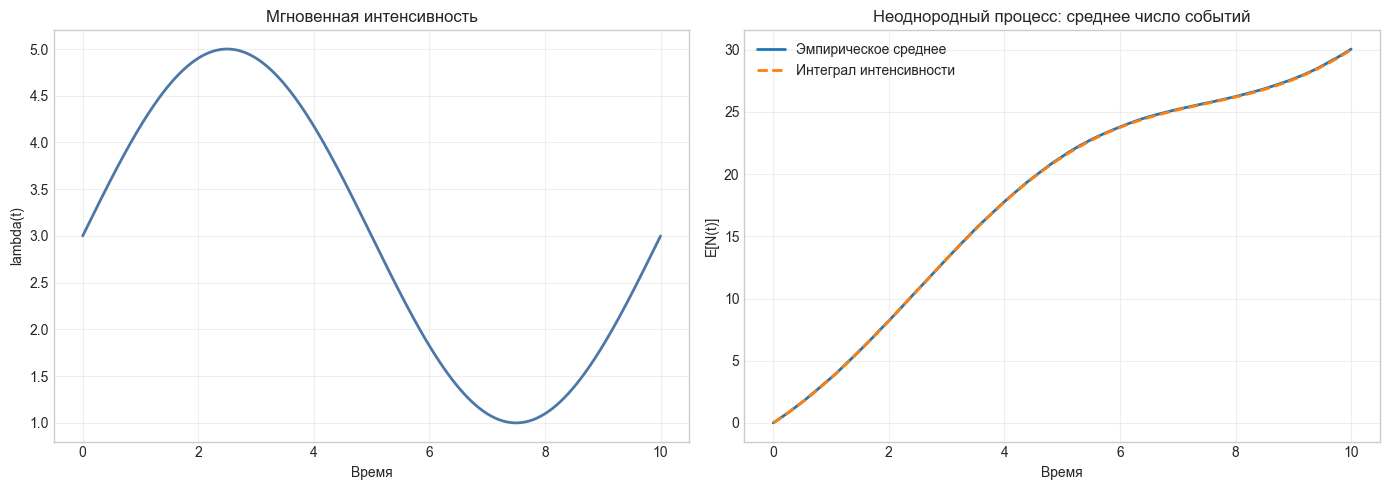

In [6]:
nonhomogeneous_time_grid = np.linspace(0.0, 10.0, 301)
nonhomogeneous_intensity = lambda x: 3.0 + 2.0 * np.sin(2.0 * np.pi * x / 10.0)

nonhomogeneous_event_times = simulate_nonhomogeneous_poisson_process_paths_by_thinning(
    number_of_paths=4000,
    final_time=10.0,
    intensity_function=nonhomogeneous_intensity,
    maximum_intensity=5.0,
    random_seed=789,
)
nonhomogeneous_paths = convert_event_times_to_count_paths(
    event_times_by_path=nonhomogeneous_event_times,
    time_grid=nonhomogeneous_time_grid,
)
nonhomogeneous_empirical_mean = nonhomogeneous_paths.mean(axis=0)
nonhomogeneous_theoretical_mean = calculate_cumulative_intensity_for_sinusoidal_poisson_process(
    time_grid=nonhomogeneous_time_grid,
    base_intensity=3.0,
    amplitude=2.0,
    period=10.0,
)

plot_nonhomogeneous_poisson_intensity_and_mean(
    time_grid=nonhomogeneous_time_grid,
    intensity_values=nonhomogeneous_intensity(nonhomogeneous_time_grid),
    empirical_mean=nonhomogeneous_empirical_mean,
    theoretical_mean=nonhomogeneous_theoretical_mean,
    title="Неоднородный процесс: среднее число событий",
);

pd.DataFrame(
    {
        "Показатель": ["E[N(2.5)] по симуляции", "E[N(2.5)] по теории", "E[N(10)] по симуляции", "E[N(10)] по теории", "Var[N(10)] по симуляции"],
        "Значение": [
            nonhomogeneous_empirical_mean[75],
            nonhomogeneous_theoretical_mean[75],
            nonhomogeneous_empirical_mean[-1],
            nonhomogeneous_theoretical_mean[-1],
            nonhomogeneous_paths[:, -1].var(),
        ],
    }
)

Среднее число событий следует не за прямой линией, а за интегралом интенсивности. В момент `2.5`, когда интенсивность была высокой в первой четверти интервала, среднее уже около `10.7043` против теоретических `10.6831`. К концу периода синусоидальная добавка интегрально компенсируется, и $E[N(10)]$ возвращается к `30`: симуляция дала `30.0635`.

Это хороший пример различия между локальной интенсивностью и накопленным средним. Интенсивность говорит, насколько быстро события появляются прямо сейчас, а интеграл интенсивности говорит, сколько событий ожидается накопить к моменту времени.

## 5. Суперпозиция и прореживание

Два фундаментальных свойства делают пуассоновские процессы очень удобными:

1. сумма независимых пуассоновских потоков снова пуассоновская, а интенсивности складываются;
2. если каждое событие независимо оставлять с вероятностью $q$, оставшийся поток снова пуассоновский с интенсивностью $q\lambda$.

Эти свойства полезны, например, когда общий поток заявок складывается из нескольких источников или когда часть заявок относится к конкретному типу.

In [7]:
superposed_counts = simulate_superposed_poisson_terminal_counts(
    number_of_replications=8000,
    final_time=4.0,
    intensities=[1.2, 2.8],
    random_seed=111,
)
retained_counts, removed_counts = simulate_thinned_poisson_terminal_counts(
    number_of_replications=8000,
    final_time=5.0,
    original_intensity=4.0,
    retention_probability=0.3,
    random_seed=222,
)

pd.DataFrame(
    {
        "Эксперимент": [
            "Суперпозиция: lambda=(1.2+2.8), T=4",
            "Прореживание: оставленные события, lambda=4, q=0.3, T=5",
            "Прореживание: удалённые события",
            "Корреляция оставленных и удалённых счётов",
        ],
        "Эмпирическое среднее": [
            superposed_counts.mean(),
            retained_counts.mean(),
            removed_counts.mean(),
            np.corrcoef(retained_counts, removed_counts)[0, 1],
        ],
        "Эмпирическая дисперсия": [
            superposed_counts.var(),
            retained_counts.var(),
            removed_counts.var(),
            np.nan,
        ],
        "Теоретическое среднее": [16.0, 6.0, 14.0, 0.0],
    }
)

,Эксперимент,Эмпирическое среднее,Эмпирическая дисперсия,Теоретическое среднее
0,"Суперпозиция: lambda=(1.2+2.8), T=4",15.9930,15.8315,16.0
1,"Прореживание: оставленные события, lambda=4, q...",5.9841,6.0839,6.0
2,Прореживание: удалённые события,13.9558,13.8580,14.0
3,Корреляция оставленных и удалённых счётов,0.0158,NaN,0.0


Для суперпозиции двух потоков с интенсивностями `1.2` и `2.8` на горизонте `4` теория даёт среднее `(1.2+2.8)*4=16`. Симуляция дала среднее `15.9930` и дисперсию `15.8315`, то есть результат снова похож на пуассоновский счёт с параметром `16`.

Для прореживания исходного потока с $\lambda=4$ и вероятностью сохранения `0.3` на горизонте `5` теория даёт среднее оставленных событий `6`. Симуляция дала `5.9841` и дисперсию `6.0839`. Удалённых событий в среднем `13.9558`, что близко к теоретическим `14`. Корреляция оставленных и удалённых счётов около `0.0158`, то есть практически нулевая: после независимого прореживания две части ведут себя как независимые пуассоновские потоки.

## Основные выводы

1. Пуассоновский процесс — модель случайного счёта событий, где среднее и дисперсия равны $\lambda t$.
2. Траектории ступенчатые: процесс изменяется только в моменты событий.
3. Времена ожидания между событиями экспоненциальны и обладают свойством отсутствия памяти.
4. Неоднородный процесс заменяет линейное среднее $\lambda t$ на интеграл интенсивности $\int_0^t\lambda(u)du$.
5. Суперпозиция складывает интенсивности, а прореживание умножает интенсивность на вероятность сохранения события.
6. Компенсированный процесс $N(t)-\lambda t$ убирает предсказуемый тренд и даёт мартингальную интуицию: после вычитания среднего темпа направленного преимущества уже нет.